In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset loaded successfully!
Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
categorical_columns = data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\aatik\AppData\Local\Temp\ipykernel_12212\1663084442.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(


In [4]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(data[column].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

In [5]:
print("Dataset shape before encoding:", data.shape)

print("\nData types:")
print(data.dtypes)

print("\nFirst 5 rows:")
print(data.head())

Dataset shape before encoding: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-

In [6]:
label_encoded_data = data.copy()

# Convert target column
label_encoded_data["Churn"] = label_encoded_data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
label_encoded_data = label_encoded_data.drop(columns=["customerID"])

# Convert TotalCharges to numeric
label_encoded_data["TotalCharges"] = pd.to_numeric(
    label_encoded_data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
label_encoded_data["TotalCharges"] = label_encoded_data["TotalCharges"].fillna(
    label_encoded_data["TotalCharges"].median()
)

print("Data prepared for Label Encoding!")

Data prepared for Label Encoding!


In [7]:
label_encoder = LabelEncoder()

categorical_features = label_encoded_data.select_dtypes(
    include=["object"]
).columns

for column in categorical_features:
    label_encoded_data[column] = label_encoder.fit_transform(
        label_encoded_data[column].astype(str)
    )

print("Label Encoding completed!")
print(label_encoded_data.head())

C:\Users\aatik\AppData\Local\Temp\ipykernel_12212\3145182911.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = label_encoded_data.select_dtypes(


Label Encoding completed!
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0      

In [8]:
print("Shape after Label Encoding:", label_encoded_data.shape)

print("\nData types:")
print(label_encoded_data.dtypes)

Shape after Label Encoding: (7043, 20)

Data types:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [9]:
one_hot_data = data.copy()

# Convert target column
one_hot_data["Churn"] = one_hot_data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
one_hot_data = one_hot_data.drop(columns=["customerID"])

# Convert TotalCharges to numeric
one_hot_data["TotalCharges"] = pd.to_numeric(
    one_hot_data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
one_hot_data["TotalCharges"] = one_hot_data["TotalCharges"].fillna(
    one_hot_data["TotalCharges"].median()
)

print("Data prepared for One-Hot Encoding!")

Data prepared for One-Hot Encoding!


In [10]:
categorical_features = one_hot_data.select_dtypes(
    include=["object"]
).columns

one_hot_data = pd.get_dummies(
    one_hot_data,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("One-Hot Encoding completed!")
print(one_hot_data.head())

One-Hot Encoding completed!
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                               0  ...  

C:\Users\aatik\AppData\Local\Temp\ipykernel_12212\1282812229.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = one_hot_data.select_dtypes(


In [11]:
print("Original dataset shape:", data.shape)
print("Label Encoded shape:", label_encoded_data.shape)
print("One-Hot Encoded shape:", one_hot_data.shape)

Original dataset shape: (7043, 21)
Label Encoded shape: (7043, 20)
One-Hot Encoded shape: (7043, 31)


In [12]:
X_label = label_encoded_data.drop("Churn", axis=1)
y_label = label_encoded_data["Churn"]

X_onehot = one_hot_data.drop("Churn", axis=1)
y_onehot = one_hot_data["Churn"]

print("Label Encoding features:", X_label.shape)
print("One-Hot Encoding features:", X_onehot.shape)

Label Encoding features: (7043, 19)
One-Hot Encoding features: (7043, 30)


In [13]:
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_label,
    y_label,
    test_size=0.2,
    random_state=42,
    stratify=y_label
)

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_onehot,
    y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_onehot
)

print("Data split completed!")

Data split completed!


In [14]:
label_model = LogisticRegression(max_iter=1000)
onehot_model = LogisticRegression(max_iter=1000)

label_model.fit(Xl_train, yl_train)
onehot_model.fit(Xo_train, yo_train)

label_predictions = label_model.predict(Xl_test)
onehot_predictions = onehot_model.predict(Xo_test)

label_accuracy = accuracy_score(yl_test, label_predictions)
onehot_accuracy = accuracy_score(yo_test, onehot_predictions)

print("Label Encoding Accuracy:", label_accuracy)
print("One-Hot Encoding Accuracy:", onehot_accuracy)

c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Label Encoding Accuracy: 0.7991483321504613
One-Hot Encoding Accuracy: 0.8041163946061036


c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
comparison = pd.DataFrame({
    "Encoding": ["Label Encoding", "One-Hot Encoding"],
    "Accuracy": [label_accuracy, onehot_accuracy]
})

print(comparison)

           Encoding  Accuracy
0    Label Encoding  0.799148
1  One-Hot Encoding  0.804116


In [16]:
comparison.to_csv(
    "encoding_performance_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")

Performance comparison saved successfully!


In [17]:
label_encoded_data.to_csv(
    "label_encoded_telco.csv",
    index=False
)

one_hot_data.to_csv(
    "one_hot_encoded_telco.csv",
    index=False
)

print("Encoded datasets saved successfully!")

Encoded datasets saved successfully!


In [18]:
print("Encoding Performance Comparison")
print(comparison)

if onehot_accuracy > label_accuracy:
    print("\nOne-Hot Encoding performed better.")
elif label_accuracy > onehot_accuracy:
    print("\nLabel Encoding performed better.")
else:
    print("\nBoth encoding methods achieved the same accuracy.")

print("\nLabel Encoding uses fewer columns but may introduce an artificial order")
print("between categories.")

print("One-Hot Encoding creates separate columns for categories and")
print("usually works better for nominal categorical features.")

Encoding Performance Comparison
           Encoding  Accuracy
0    Label Encoding  0.799148
1  One-Hot Encoding  0.804116

One-Hot Encoding performed better.

Label Encoding uses fewer columns but may introduce an artificial order
between categories.
One-Hot Encoding creates separate columns for categories and
usually works better for nominal categorical features.


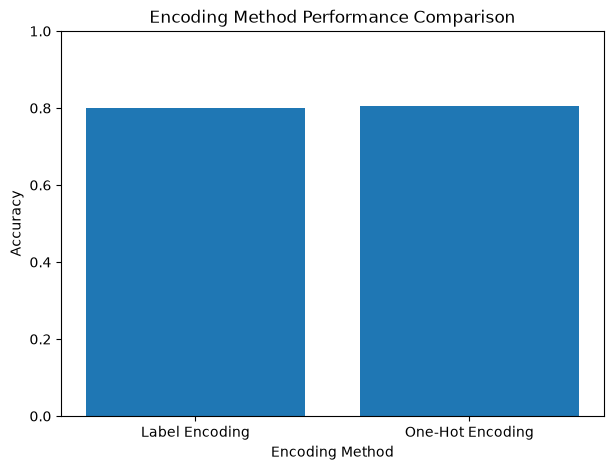

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(comparison["Encoding"], comparison["Accuracy"])

plt.title("Encoding Method Performance Comparison")
plt.xlabel("Encoding Method")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [20]:
print("DAY 22 SUMMARY")
print("-" * 40)
print("1. Identified categorical features.")
print("2. Applied Label Encoding.")
print("3. Applied One-Hot Encoding.")
print("4. Compared dataset structures.")
print("5. Trained Logistic Regression models.")
print("6. Compared model accuracy.")
print("7. Saved encoded datasets and performance report.")

DAY 22 SUMMARY
----------------------------------------
1. Identified categorical features.
2. Applied Label Encoding.
3. Applied One-Hot Encoding.
4. Compared dataset structures.
5. Trained Logistic Regression models.
6. Compared model accuracy.
7. Saved encoded datasets and performance report.
